
ВЫБОР РЕЖИМА РАБОТЫ
1 - Сгенерировать новые данные и выполнить анализ
2 - Загрузить локальный data.csv и выполнить анализ
--------------------------------------------------
Ваш выбор (1 или 2): 1

✨ Будет сгенерирован новый синтетический датасет

ЗАПУСК LLM-АГЕНТА

Генерация данных...
Расчёт метрик...
   ✅ Месяц 1: active=1000, paid=1000, revenue=$16,490, ARPU=$16.49

 Проверка данных...
   ✅ Выполнено 16 проверок

 Формирование отчёта...
   → Пробуем модель: openai/gpt-chat-latest
   ⚠️ Модель openai/gpt-chat-latest требует оплаты, пробуем другую...
   → Пробуем модель: qwen/qwen3.7-max
   ⚠️ Модель qwen/qwen3.7-max требует оплаты, пробуем другую...
   → Пробуем модель: deepseek/deepseek-v4-flash:free
   ⚠️ Rate limit на deepseek/deepseek-v4-flash:free, пробуем другую...
   → Пробуем модель: anthropic/claude-opus-4.7-fast
   ⚠️ Модель anthropic/claude-opus-4.7-fast требует оплаты, пробуем другую...
   → Пробуем модель: google/gemini-3.5-flash
   ⚠️ Модель google/gemini-3.5-flash треб

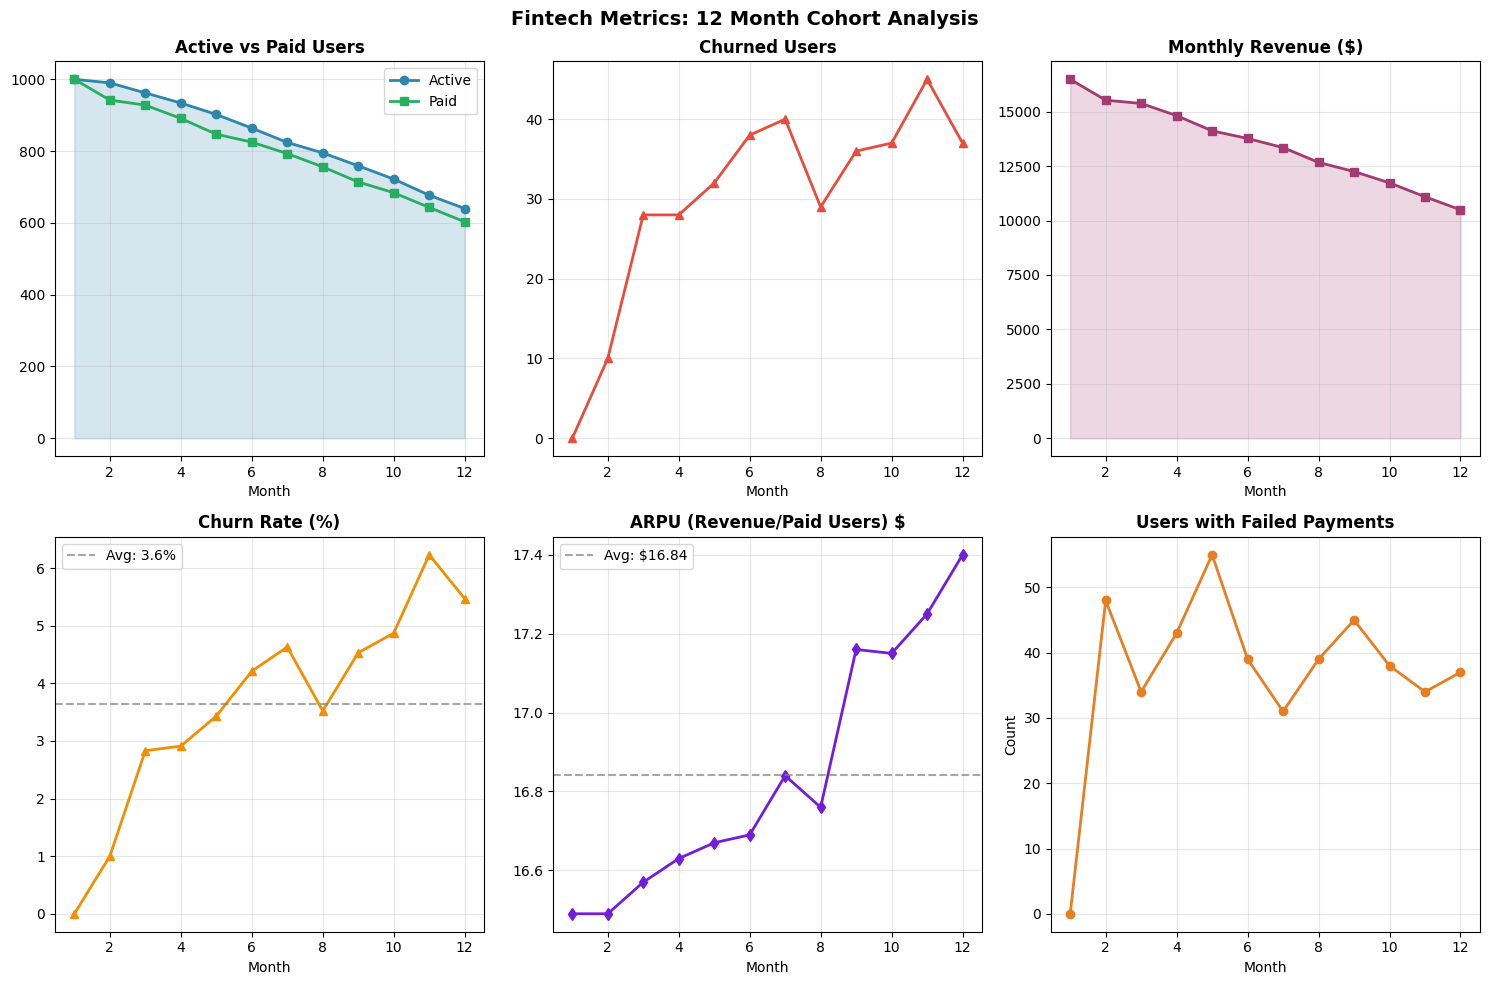

In [22]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tenacity import retry, stop_after_attempt, wait_exponential
import time
import warnings
warnings.filterwarnings('ignore')

# ========== НАСТРОЙКА OPENROUTER ==========
OPENROUTER_API_KEY = "YOUR_API_KEY_HERE"

client = openai.OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

FREE_MODELS = [
    "openai/gpt-chat-latest",
    "qwen/qwen3.7-max",
    "deepseek/deepseek-v4-flash:free",
    "anthropic/claude-opus-4.7-fast",
    "google/gemini-3.5-flash",
    "google/gemini-3.1-flash-lite",
    "x-ai/grok-build-0.1",
    "perceptron/perceptron-mk1",
    "inclusionai/ring-2.6-1t",


]


class LLMFintechAgent:

    def __init__(self, n_users=1000, months=12, use_local_data=False):
        self.n_users = n_users
        self.months = months
        self.use_local_data = use_local_data
        self.data = None
        self.metrics = None
        self.report = None
        self.quality_checks = None

    def load_local_data(self, filename='data.csv'):
        """Загрузка данных из локального CSV."""
        print(f"Загрузка локальных данных из {filename}...")

        try:
            self.data = pd.read_csv(filename)

            # Проверка наличия всех необходимых колонок
            required_columns = ['user_id', 'month', 'plan', 'monthly_price', 'payment_status', 'amount_paid', 'is_active']
            missing_columns = [col for col in required_columns if col not in self.data.columns]

            if missing_columns:
                raise ValueError(f"Отсутствуют обязательные колонки: {missing_columns}")

            # Определяем количество месяцев и пользователей из данных
            self.months = self.data['month'].max()
            self.n_users = self.data['user_id'].nunique()

            print(f"   ✅ Загружено: {len(self.data)} записей")
            print(f"   ✅ Пользователей: {self.n_users}, Месяцев: {self.months}")

            return self.data

        except FileNotFoundError:
            print(f"   ❌ Файл {filename} не найден!")
            print("   → Переключаюсь на генерацию данных...")
            self.use_local_data = False
            return self.generate_synthetic_data()
        except Exception as e:
            print(f"   ❌ Ошибка загрузки: {e}")
            print("   → Переключаюсь на генерацию данных...")
            self.use_local_data = False
            return self.generate_synthetic_data()

    def generate_synthetic_data(self, seed=42):
        """Генерирует данные строго по ТЗ."""
        np.random.seed(seed)

        print("Генерация данных...")

        plans = {
            'basic': {'price': 9.99, 'prob': 0.5, 'churn_factor': 1.2},
            'pro': {'price': 19.99, 'prob': 0.35, 'churn_factor': 0.8},
            'premium': {'price': 29.99, 'prob': 0.15, 'churn_factor': 0.5}
        }

        user_plans = np.random.choice(
            list(plans.keys()),
            size=self.n_users,
            p=[p['prob'] for p in plans.values()]
        )
        user_prices = [plans[p]['price'] for p in user_plans]
        user_factors = [plans[p]['churn_factor'] for p in user_plans]

        individual_risks = np.random.beta(2, 5, self.n_users) * np.array(user_factors)
        active = np.ones(self.n_users, dtype=bool)

        records = []

        for month in range(1, self.months + 1):
            for user_id in range(1, self.n_users + 1):
                idx = user_id - 1

                if not active[idx]:
                    records.append({
                        'user_id': user_id,
                        'month': month,
                        'plan': user_plans[idx],
                        'monthly_price': user_prices[idx],
                        'payment_status': 'failed',
                        'amount_paid': 0.0,
                        'is_active': False
                    })
                    continue

                # ИСПРАВЛЕНО: Месяц 1 — 100% успешных платежей
                if month == 1:
                    records.append({
                        'user_id': user_id,
                        'month': month,
                        'plan': user_plans[idx],
                        'monthly_price': user_prices[idx],
                        'payment_status': 'paid',
                        'amount_paid': user_prices[idx],
                        'is_active': True
                    })
                    continue

                # Месяцы 2+
                # Проверка оттока (churn)
                base_churn = 0.03 + ((month - 1) / self.months) * 0.25
                churn_prob = min(0.4, base_churn * individual_risks[idx])

                if np.random.random() < churn_prob:
                    # Пользователь уходит
                    records.append({
                        'user_id': user_id,
                        'month': month,
                        'plan': user_plans[idx],
                        'monthly_price': user_prices[idx],
                        'payment_status': 'failed',
                        'amount_paid': 0.0,
                        'is_active': False
                    })
                    active[idx] = False
                else:
                    # Пользователь остаётся — проверяем успешность платежа
                    payment_success = np.random.random() < 0.95

                    if payment_success:
                        records.append({
                            'user_id': user_id,
                            'month': month,
                            'plan': user_plans[idx],
                            'monthly_price': user_prices[idx],
                            'payment_status': 'paid',
                            'amount_paid': user_prices[idx],
                            'is_active': True
                        })
                    else:
                        # Неудачный платёж, но пользователь остаётся активным (grace period)
                        records.append({
                            'user_id': user_id,
                            'month': month,
                            'plan': user_plans[idx],
                            'monthly_price': user_prices[idx],
                            'payment_status': 'failed',
                            'amount_paid': 0.0,
                            'is_active': True
                        })

        self.data = pd.DataFrame(records)

        return self.data

    def calculate_metrics(self):
        """Расчёт метрик с корректным ARPU = revenue / paid_users."""
        print("Расчёт метрик...")

        metrics_list = []

        for month in range(1, self.months + 1):
            month_data = self.data[self.data['month'] == month]
            prev_month_data = self.data[self.data['month'] == month - 1] if month > 1 else None

            active_users = month_data['is_active'].sum()
            paid_users = month_data[month_data['payment_status'] == 'paid'].shape[0]

            if prev_month_data is not None:
                prev_active_ids = set(prev_month_data[prev_month_data['is_active']]['user_id'])
                curr_active_ids = set(month_data[month_data['is_active']]['user_id'])
                churned_users = len(prev_active_ids - curr_active_ids)
            else:
                churned_users = 0

            monthly_revenue = month_data['amount_paid'].sum()

            if prev_month_data is not None:
                prev_active = prev_month_data['is_active'].sum()
                churn_rate = churned_users / prev_active if prev_active > 0 else 0
            else:
                churn_rate = 0.0

            # ИСПРАВЛЕНО: ARPU = revenue / paid_users
            arpu = monthly_revenue / paid_users if paid_users > 0 else 0.0

            metrics_list.append({
                'month': month,
                'active_users': int(active_users),
                'paid_users': int(paid_users),
                'churned_users': int(churned_users),
                'monthly_revenue': round(monthly_revenue, 2),
                'churn_rate': round(churn_rate, 4),
                'arpu': round(arpu, 2)
            })

        self.metrics = pd.DataFrame(metrics_list)

        print(f"   ✅ Месяц 1: active={self.metrics['active_users'].iloc[0]}, "
              f"paid={self.metrics['paid_users'].iloc[0]}, "
              f"revenue=${self.metrics['monthly_revenue'].iloc[0]:,.0f}, "
              f"ARPU=${self.metrics['arpu'].iloc[0]:.2f}")

        return self.metrics

    def run_quality_checks(self):
        """Проверки данных."""
        print("\n Проверка данных...")

        checks = []

        # 1. Дубликаты
        full_duplicates = self.data.duplicated().sum()
        checks.append(f"full_duplicates: {full_duplicates}")

        key_duplicates = self.data.duplicated(subset=['user_id', 'month']).sum()
        checks.append(f"key_duplicates_user_month: {key_duplicates}")

        # 2. Соответствие корректным полям
        required_columns = ['user_id', 'month', 'plan', 'monthly_price', 'payment_status', 'amount_paid', 'is_active']
        missing_columns = [col for col in required_columns if col not in self.data.columns]
        checks.append(f"missing_required_columns_count: {len(missing_columns)}")

        # 3. Корректность payment_status
        valid_statuses = ['paid', 'failed']
        invalid_statuses = self.data[~self.data['payment_status'].isin(valid_statuses)].shape[0]
        checks.append(f"invalid_payment_status_count: {invalid_statuses}")

        # 4. Согласованность amount_paid и payment_status
        paid_mismatch = self.data[
            (self.data['payment_status'] == 'paid') &
            (self.data['amount_paid'] != self.data['monthly_price'])
        ].shape[0]
        checks.append(f"paid_status_amount_mismatch: {paid_mismatch}")

        failed_nonzero = self.data[
            (self.data['payment_status'] == 'failed') &
            (self.data['amount_paid'] != 0)
        ].shape[0]
        checks.append(f"failed_status_nonzero_amount: {failed_nonzero}")


        # 6. Цены соответствуют плану
        price_by_plan = {'basic': 9.99, 'pro': 19.99, 'premium': 29.99}
        price_mismatch = 0
        for plan, expected_price in price_by_plan.items():
            mismatches = self.data[
                (self.data['plan'] == plan) &
                (self.data['monthly_price'] != expected_price)
            ].shape[0]
            price_mismatch += mismatches
        checks.append(f"price_plan_mismatch: {price_mismatch}")

        # 7. NULL значения
        null_count = self.data.isnull().sum().sum()
        checks.append(f"null_values_count: {null_count}")

        # 8. Некорректные user_id
        invalid_user_ids = ((self.data['user_id'] < 1) | (self.data['user_id'] > self.n_users)).sum()
        checks.append(f"invalid_user_ids_count: {invalid_user_ids}")

        # 9. Отрицательные значения в метриках
        negative_active = (self.metrics['active_users'] < 0).sum()
        negative_revenue = (self.metrics['monthly_revenue'] < 0).sum()
        checks.append(f"negative_active_users_count: {negative_active}")
        checks.append(f"negative_revenue_count: {negative_revenue}")

        # 10. Монотонность - при отсутствии новых пользователей корректная проверка
        is_monotonic = int(self.metrics['active_users'].is_monotonic_decreasing)
        checks.append(f"active_users_monotonically_decreasing: {is_monotonic}")


        # 11. Churn rate вне диапазона
        churn_out_of_range = ((self.metrics['churn_rate'] < 0) | (self.metrics['churn_rate'] > 1)).sum()
        checks.append(f"churn_rate_out_of_range_0_1: {churn_out_of_range}")

        # 12. paid_users не может быть больше active_users
        paid_exceeds_active = (self.metrics['paid_users'] > self.metrics['active_users']).sum()
        checks.append(f"paid_users_exceed_active_users: {paid_exceeds_active}")

        # 13. Выбросы (контекстно зависимо, может быть ложным сигналом при маленькой выборке)
        if len(self.metrics) > 2:
            z_scores = np.abs(stats.zscore(self.metrics['churn_rate']))
            outliers = sum(z_scores > 2)
        else:
            outliers = 0
        checks.append(f"churn_rate_statistical_outliers_zscore_gt_2: {outliers}")

        # 14. Пропущенные месяцы
        expected_months = set(range(1, self.months + 1))
        actual_months = set(self.metrics['month'])
        missing_months_count = len(expected_months - actual_months)
        checks.append(f"missing_months_count: {missing_months_count}")


        self.quality_checks = checks

        print(f"   ✅ Выполнено {len(checks)} проверок")

        return checks

    def get_quality_checks_for_llm(self):
        """Возвращает проверки для LLM."""
        if not self.quality_checks:
            self.run_quality_checks()

        return "\n".join(self.quality_checks)

    @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=5, min=10, max=60))
    def call_llm(self, prompt, system_prompt=None):
        """Вызов LLM."""
        if system_prompt is None:
            system_prompt = "Ты — финансовый аналитик подписочных сервисов. Отвечай строго по структуре, кратко и по делу."

        for model in FREE_MODELS:
            try:
                print(f"   → Пробуем модель: {model}")
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": prompt}
                    ],
                    temperature=0.3,
                    max_tokens=2000
                )
                print(f"   ✅ Успешно с моделью: {model}")
                return response.choices[0].message.content
            except Exception as e:
                error_msg = str(e)
                if "429" in error_msg:
                    print(f"   ⚠️ Rate limit на {model}, пробуем другую...")
                    time.sleep(5)
                    continue
                elif "402" in error_msg:
                    print(f"   ⚠️ Модель {model} требует оплаты, пробуем другую...")
                    continue
                else:
                    print(f"   ⚠️ Ошибка {model}: {error_msg[:80]}...")
                    continue

        raise Exception("❌ Все модели недоступны")

    def generate_report(self):
        print("\n Формирование отчёта...")

        report_data = self.metrics[[
            'month',
            'active_users',
            'paid_users',
            'churned_users',
            'monthly_revenue',
            'churn_rate',
            'arpu'
        ]].copy()
        report_data['churn_rate_pct'] = (report_data['churn_rate'] * 100).round(1)

        quality_checks_text = self.get_quality_checks_for_llm()

        table_string = report_data[[
            'month', 'active_users', 'paid_users', 'churned_users',
            'monthly_revenue', 'churn_rate_pct', 'arpu'
        ]].to_string(index=False)

        prompt = f"""
            Твоя задача — проанализировать метрики подписочного сервиса.

            [ANTI-HALLUCINATION GUARDRAILS & RULES]
            1. ТОЛЬКО ФАКТЫ (GROUNDING): Используй исключительно цифры из предоставленных таблиц. Запрещено выдумывать недостающие данные, внешние факторы или причины изменений, если их нет в тексте.
            2. MATH SAFETY: LLM часто ошибаются в расчетах. НЕ считай проценты роста/падения (MoM%, CAGR). Используй только абсолютные значения из таблицы (например: "в месяц 4 выручка $X, в месяц 5 упала до $Y").
            3. NO FILLER: Не пиши вступлений ("Конечно", "Ниже представлен анализ"). Начинай ответ СТРОГО с заголовка "## 1. Executive Summary".
            4. COMPLETENESS: Сгенерируй все 6 разделов в рамках одного сообщения. Не прерывайся.
            5. Проверки качества используются ТОЛЬКО в пункте 5 для оценки достоверности данных. В пунктах 1-4 и 6 данные считаются достоверными (даже если в проверках есть ошибки — это отдельный вопрос)

            [ОПРЕДЕЛЕНИЯ МЕТРИК — КОНТЕКСТ ДЛЯ КОРРЕКТНОЙ ИНТЕРПРЕТАЦИИ]
            - **month** - Нумерация месяца, счет начинается с 1.
            - **active_users**: Количество пользователей, чей аккаунт активен в данном месяце. Они могут как платить, так и не платить (grace period, проблемы с биллингом).
            - **paid_users**: Количество пользователей, которые фактически совершили успешный платёж в этом месяце. Это подмножество active_users.
            - **churned_users**: Количество пользователей, которые были активны в предыдущем месяце, но стали неактивны в текущем. Это строгая потеря клиента.
            - **monthly_revenue**: Общая сумма успешных платежей за месяц (в долларах). Рассчитывается как сумма amount_paid для всех paid_users.
            - **churn_rate_pct**: Процент оттока. Формула = churned_users / active_users(prev_month) * 100. Не путай с процентом неплатежей.
            - **arpu**: Средний доход на платящего пользователя. Формула = monthly_revenue / paid_users. **ВАЖНО: НЕ на active_users, а именно на paid_users**.

            [ОПИСАНИЕ ПРОВЕРОК КАЧЕСТВА ДАННЫХ — ЧТО КАЖДАЯ ПРОВЕРКА ЗНАЧИТ]
            Ниже перечислены результаты автоматических проверок целостности данных:
            1. **full_duplicates** — количество полностью дублированных строк в датасете. Должно быть 0.
            2. **key_duplicates_user_month** — сколько раз встречается пара (user_id, month) больше одного раза. Критическая ошибка, если >0.
            3. **missing_required_columns_count** — сколько обязательных колонок отсутствует (user_id, month, plan, monthly_price, payment_status, amount_paid, is_active).
            4. **invalid_payment_status_count** — сколько строк имеют payment_status не равный 'paid' или 'failed'.
            5. **paid_status_amount_mismatch** — сколько раз при payment_status='paid' сумма amount_paid не равна monthly_price. Указывает на ошибки биллинга.
            6. **failed_status_nonzero_amount** — сколько раз при payment_status='failed' amount_paid ≠ 0. Логическая ошибка.
            7. **inactive_with_paid_status** — сколько раз is_active=False, но payment_status='paid'. Невозможная ситуация в реальности.
            8. **price_plan_mismatch** — сколько раз цена не соответствует плану (basic=$9.99, pro=$19.99, premium=$29.99).
            9. **null_values_count** — общее количество NULL значений во всём датасете. Чем ближе к 0, тем лучше.
            10. **invalid_user_ids_count** — сколько раз user_id < 1 или > максимального ID.
            11. **negative_active_users_count** — сколько месяцев active_users отрицательный (ошибка, должно быть 0).
            12. **negative_revenue_count** — сколько месяцев monthly_revenue отрицательный (ошибка, должно быть 0).
            13. **active_users_monotonically_decreasing** — 1 если active_users только уменьшается или остаётся неизменным, 0 если есть рост.
            14. **churn_rate_out_of_range_0_1** — сколько раз churn_rate выходит за пределы [0, 1] (должно быть 0).
            15. **paid_users_exceed_active_users** — сколько раз paid_users > active_users (невозможно, так как paid_users — подмножество active_users).
            16. **churn_rate_statistical_outliers_zscore_gt_2** — количество месяцев, где churn_rate статистически выбивается (z-score > 2). Указывает на аномалии.
            17. **missing_months_count** — сколько месяцев отсутствует в данных (должно быть 0).


            ===== ДАННЫЕ ПО МЕСЯЦАМ =====
            {table_string}

            ===== РЕЗУЛЬТАТЫ ПРОВЕРОК КАЧЕСТВА ДАННЫХ =====
            {quality_checks_text}

            ===== ФОРМАТ ОТВЕТА (СТРОГО СОБЛЮДАЙ СТРУКТУРУ) =====

            ## 1. Executive Summary
            (Краткое резюме: ключевые факты за 12 месяцев, общие тренды активных пользователей и выручки).

            ## 2. Monthly Revenue Trend
            (Динамика выручки: укажи месяцы с минимальным и максимальным значением, опиши характер тренда).

            ## 3. Churn Trend
            (Динамика оттока: месяцы с пиковым churn_rate_pct и churned_users. Сравни начало и конец периода).

            ## 4. ARPU Trend
            (Динамика ARPU. Опиши, как менялась выручка на одного платящего пользователя).

            ## 5. Data Quality Checks
            (Проанализируй блок "ПРОВЕРКИ КАЧЕСТВА ДАННЫХ". Есть ли критические ошибки, пропуски или аномалии? Сделай вывод о степени доверия к датасету).

            ## 6. Business Interpretation

            **ВАЖНО: Каждый вывод должен завершаться конкретным ACTION ITEM в формате:**
            `→ ACTION: [Что сделать] | WHEN: [Срок] | SUCCESS: [Как измерить]`

            ### КРИТИЧЕСКИЙ ПРИОРИТЕТ (решить за 0-30 дней)
            (1-2 пункта с цифрами из таблицы, угрожающие выручке)

            Формат для каждого пункта:
            **Проблема**: [конкретная метрика = значение, месяц]
            **Корень**: [что данные говорят о причине, НЕ придумывать]
            → ACTION: ... | WHEN: ... | SUCCESS: ...

            ### СРЕДНИЙ ПРИОРИТЕТ (оптимизировать за 30-90 дней)
            (1-2 пункта для улучшения Retention/ARPU)

            ### НИЗКИЙ ПРИОРИТЕТ (стратегия на 90-365 дней)
            (1 пункт для долгосрочного роста)

            ---
            **ПРИМЕР (не включай в ответ, только как образец):**

            ### КРИТИЧЕСКИЙ ПРИОРИТЕТ
            **Проблема**: Churn rate вырос с 0% (мес 1) до 5.5% (мес 12), потеряно 360 платящих пользователей
            **Корень**: Отток ускоряется после месяца 6 — данные не показывают причину, требуется анализ
            → ACTION: Провести exit-poll среди 50 ушедших пользователей | WHEN: 14 дней | SUCCESS: Выявлены top-3 причины ухода

            ### СРЕДНИЙ ПРИОРИТЕТ
            **Проблема**: ARPU вырос на $0.91 (5.5%) на фоне падения платящей базы на 39.7%
            **Корень**: Возможный переток на дорогие планы, но retention на них неизвестен
            → ACTION: Рассчитать когортный LTV для Basic vs Pro vs Premium | WHEN: 21 день | SUCCESS: Понимание, какой план даёт лучший 12-месячный LTV
            """


        self.report = self.call_llm(prompt)
        return self.report

    def plot_metrics(self):
        """Визуализация."""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Active vs Paid Users
        axes[0,0].plot(self.metrics['month'], self.metrics['active_users'], marker='o', color='#2E86AB', linewidth=2, label='Active')
        axes[0,0].plot(self.metrics['month'], self.metrics['paid_users'], marker='s', color='#27AE60', linewidth=2, label='Paid')
        axes[0,0].fill_between(self.metrics['month'], 0, self.metrics['active_users'], alpha=0.2, color='#2E86AB')
        axes[0,0].set_title('Active vs Paid Users', fontweight='bold')
        axes[0,0].set_xlabel('Month')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # Churned Users
        axes[0,1].plot(self.metrics['month'], self.metrics['churned_users'], marker='^', color='#E74C3C', linewidth=2)
        axes[0,1].set_title('Churned Users', fontweight='bold')
        axes[0,1].set_xlabel('Month')
        axes[0,1].grid(True, alpha=0.3)

        # Monthly Revenue
        axes[0,2].plot(self.metrics['month'], self.metrics['monthly_revenue'], marker='s', color='#A23B72', linewidth=2)
        axes[0,2].fill_between(self.metrics['month'], 0, self.metrics['monthly_revenue'], alpha=0.2, color='#A23B72')
        axes[0,2].set_title('Monthly Revenue ($)', fontweight='bold')
        axes[0,2].set_xlabel('Month')
        axes[0,2].grid(True, alpha=0.3)

        # Churn Rate
        axes[1,0].plot(self.metrics['month'], self.metrics['churn_rate']*100, marker='^', color='#F18F01', linewidth=2)
        axes[1,0].axhline(y=self.metrics['churn_rate'].mean()*100, linestyle='--', color='gray', alpha=0.7, label=f"Avg: {self.metrics['churn_rate'].mean()*100:.1f}%")
        axes[1,0].set_title('Churn Rate (%)', fontweight='bold')
        axes[1,0].set_xlabel('Month')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        # ARPU (теперь корректный)
        axes[1,1].plot(self.metrics['month'], self.metrics['arpu'], marker='d', color='#731DD8', linewidth=2)
        axes[1,1].axhline(y=self.metrics['arpu'].mean(), linestyle='--', color='gray', alpha=0.7, label=f"Avg: ${self.metrics['arpu'].mean():.2f}")
        axes[1,1].set_title('ARPU (Revenue/Paid Users) $', fontweight='bold')
        axes[1,1].set_xlabel('Month')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        # Gap: Active - Paid
        axes[1,2].plot(self.metrics['month'], self.metrics['active_users'] - self.metrics['paid_users'],
                      marker='o', color='#E67E22', linewidth=2)
        axes[1,2].set_title('Users with Failed Payments', fontweight='bold')
        axes[1,2].set_xlabel('Month')
        axes[1,2].set_ylabel('Count')
        axes[1,2].grid(True, alpha=0.3)

        plt.suptitle('Fintech Metrics: 12 Month Cohort Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def export_data(self):
        """Экспорт данных."""
        if not self.use_local_data:
            self.data.to_csv('data.csv', index=False)
            self.metrics.to_csv('metrics.csv', index=False)
            print("\n Данные экспортированы:")
            print(f"   - data.csv ({len(self.data)} записей)")
            print(f"   - metrics.csv ({len(self.metrics)} записей)")
        else:
            print("\n Данные не экспортированы (использован локальный файл)")

    def run(self):
        """Запуск агента."""
        print("\n" + "="*70)
        print("ЗАПУСК LLM-АГЕНТА")
        print("="*70 + "\n")

        if self.use_local_data:
            self.load_local_data()
        else:
            self.generate_synthetic_data()

        self.calculate_metrics()
        self.run_quality_checks()
        self.generate_report()
        self.export_data()

        print("\n" + "="*80)
        print("📊 ИТОГОВЫЙ ОТЧЁТ")
        print("="*80)
        print(self.report)
        print("="*80)

        self.plot_metrics()

        return self


# ========== ЗАПУСК С ВЫБОРОМ РЕЖИМА ==========
if __name__ == "__main__":
    if OPENROUTER_API_KEY == "YOUR_API_KEY_HERE":
        print("⚠️ Вставьте API ключ OpenRouter")
        print("Получить: https://openrouter.ai/keys")
    else:
        print("\n" + "="*50)
        print("ВЫБОР РЕЖИМА РАБОТЫ")
        print("="*50)
        print("1 - Сгенерировать новые данные и выполнить анализ")
        print("2 - Загрузить локальный data.csv и выполнить анализ")
        print("-"*50)

        while True:
            try:
                mode = int(input("Ваш выбор (1 или 2): "))
                if mode in [1, 2]:
                    break
                else:
                    print("❌ Пожалуйста, введите 1 или 2")
            except ValueError:
                print("❌ Пожалуйста, введите число 1 или 2")

        use_local = (mode == 2)

        if use_local:
            print("\n📁 Будет использован файл data.csv в текущей директории")
            agent = LLMFintechAgent(use_local_data=True)
        else:
            print("\n✨ Будет сгенерирован новый синтетический датасет")
            agent = LLMFintechAgent(n_users=1000, months=12, use_local_data=False)

        agent.run()